# Exploring the Dynamics of the Habit-Portfolio Model

The consumption-saving model with portfolio choice and habit formation is fairly novel, and thus the role of habit formation is not well understood. This notebook presents some exercises that explore how model outcomes evolve in response to an unexpected shock, using an infinite horizon framework.

In [1]:
from HARK.models import HabitPortfolioConsumerType, RiskyAssetConsumerType
from HARK.ConsumptionSaving.ConsHabitPortfolioModel import (
    HabitPortfolioConsumerType_defaults,
)
from time import time
import numpy as np
import matplotlib.pyplot as plt

mystr = lambda x: "{:.3f}".format(x)

In [2]:
# Make a parameter dictionary
my_params = HabitPortfolioConsumerType_defaults.copy()
del my_params["constructors"]  # don't want to overwrite these
my_params["CRRA"] = 6.0
my_params["Rfree"] = [1.01]
my_params["RiskyAvg"] = 1.04
my_params["RiskyStd"] = 0.18
my_params["RiskyShareFixed"] = None
my_params["HabitRte"] = 0.1
my_params["hLogInitMean"] = 0.0
my_params["cycles"] = 0
my_params["T_sim"] = 700

T_burn = 500

In [3]:
# Define a function that runs an MIT shock experiment
def run_MIT_shock_experiment(Agent, var, factor, T_shock):
    # Execute the MIT shock experiment
    Agent.initialize_sym()
    Agent.symulate(T_shock)
    if var in Agent._simulator.data:
        Agent._simulator.data[var] *= factor
    Agent.symulate()

    # Extract average sequences of assets, consumption, risky asset share, and habits
    C = np.mean(Agent.hystory["cNrm"], axis=1)
    A = np.mean(Agent.hystory["aNrm"], axis=1)
    S = np.mean(Agent.hystory["Share"], axis=1)
    if "hNrm" in Agent.hystory:
        H = np.mean(Agent.hystory["hNrm"], axis=1)
    else:
        H = np.ones_like(C)

    return C, A, S, H

In [4]:
# Define a function to run an experiment on several types and return lists
def run_experiment_on_types(Agents, var, factor, T_shock):
    C_out = []
    A_out = []
    S_out = []
    H_out = []
    for Agent in Agents:
        C, A, S, H = run_MIT_shock_experiment(Agent, var, factor, T_shock)
        C_out.append(C)
        A_out.append(A)
        S_out.append(S)
        H_out.append(H)
    return C_out, A_out, S_out, H_out

In [5]:
# Define a function to compare the results of experiments across types
def make_experiment_comparison_plot(X, T0, outcome, labels):
    t_vec = np.arange(-20, len(X[0]) - T0)
    for j in range(len(X)):
        plt.plot(t_vec, X[j][(T0 - 20) :], "-")
    plt.xlabel(r"time $t$")
    plt.ylabel(outcome)
    plt.legend(labels, loc=(0.05, -0.2), ncols=4)
    plt.tight_layout()
    plt.show()

In [6]:
# Define a function to draw four comparison plots
def draw_four_plots(CASH, T0, labels):
    make_experiment_comparison_plot(CASH[0], T0, r"Consumption $c_t$", labels)
    make_experiment_comparison_plot(CASH[1], T0, r"End-of-period assets $a_t$", labels)
    make_experiment_comparison_plot(CASH[2], T0, r"Risky asset share $s_t$", labels)
    make_experiment_comparison_plot(CASH[3], T0, r"Habit stock $h_t$", labels)

In [7]:
# Make and solve the base type with no habits
BaseType = RiskyAssetConsumerType(**my_params)
t0 = time()
BaseType.solve()
t1 = time()
print("Solving the model with no habits took " + mystr(t1 - t0) + " seconds.")

Solving the model with no habits took 4.649 seconds.


In [8]:
# Make and solve agents with low, medium, and high habits
alpha_list = [0.2, 0.5, 0.8]
HabitTypes = []
for j in range(len(alpha_list)):
    t0 = time()
    temp_params = my_params.copy()
    temp_params["HabitWgt"] = alpha_list[j]
    HabitTypes.append(HabitPortfolioConsumerType(**temp_params))
    HabitTypes[-1].solve()
    t1 = time()
    print(
        "Solving the habit type with alpha="
        + mystr(alpha_list[j])
        + " took "
        + mystr(t1 - t0)
        + " seconds."
    )

Solving the habit type with alpha=0.200 took 285.672 seconds.
Solving the habit type with alpha=0.500 took 194.409 seconds.
Solving the habit type with alpha=0.800 took 149.793 seconds.


In [9]:
# Define type labels
my_agents = [BaseType] + HabitTypes
type_labels = [r"$\alpha=0$"]
for j in range(len(alpha_list)):
    type_labels.append(r"$\alpha$=" + str(alpha_list[j]))

In [10]:
# Run an experiment in which wealth is shocked downward by 50%
t0 = time()
CASH_neg_wealth = run_experiment_on_types(my_agents, "aNrm", 0.5, T_burn)
t1 = time()
print("The negative wealth shock experiment took " + mystr(t1 - t0) + " seconds.")

The negative wealth shock experiment took 46.310 seconds.


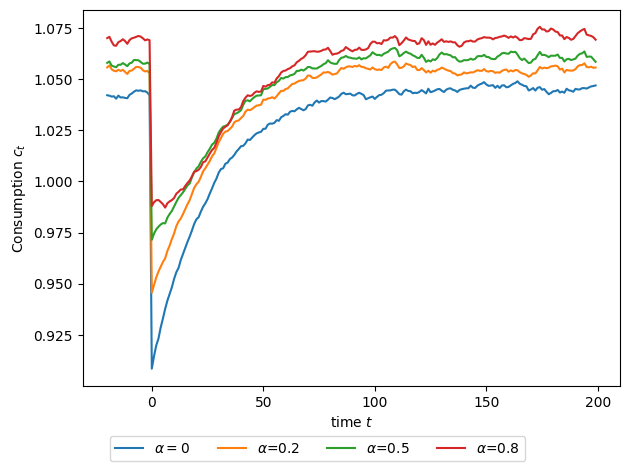

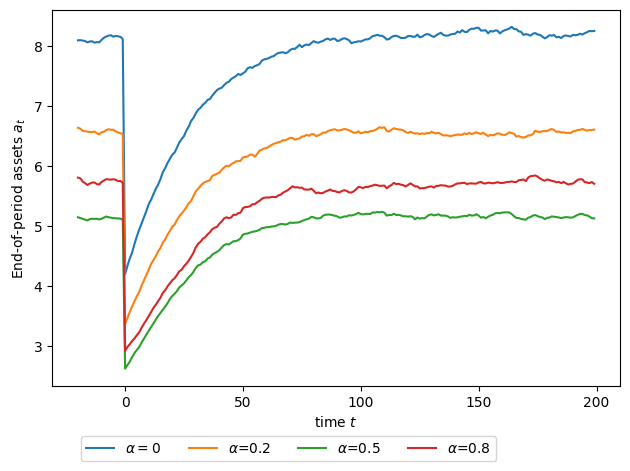

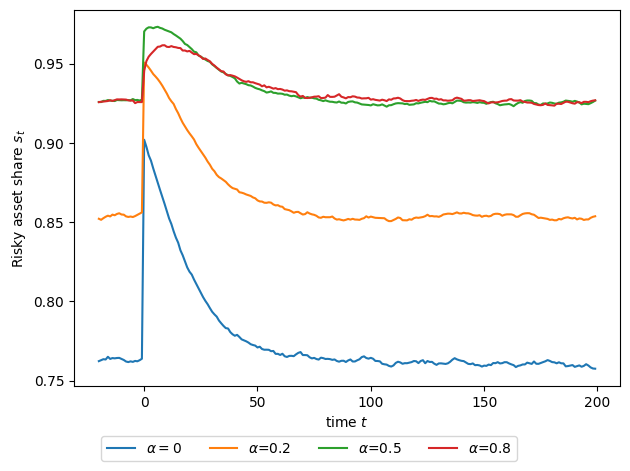

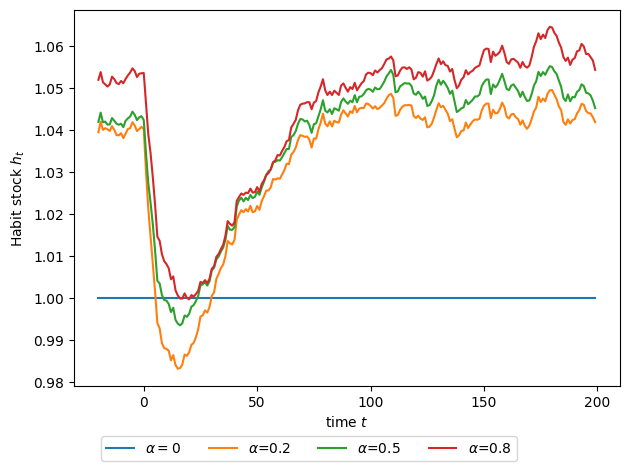

In [11]:
# Plot the results of the negative wealth shock experiment
draw_four_plots(CASH_neg_wealth, T_burn, type_labels)

In [12]:
# Run an experiment in which wealth is shocked upward by 50%
t0 = time()
CASH_pos_wealth = run_experiment_on_types(my_agents, "aNrm", 1.5, T_burn)
t1 = time()
print("The positive wealth shock experiment took " + mystr(t1 - t0) + " seconds.")

The positive wealth shock experiment took 46.914 seconds.


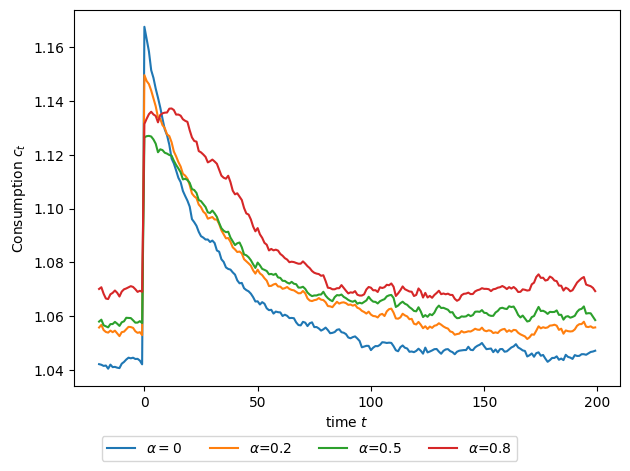

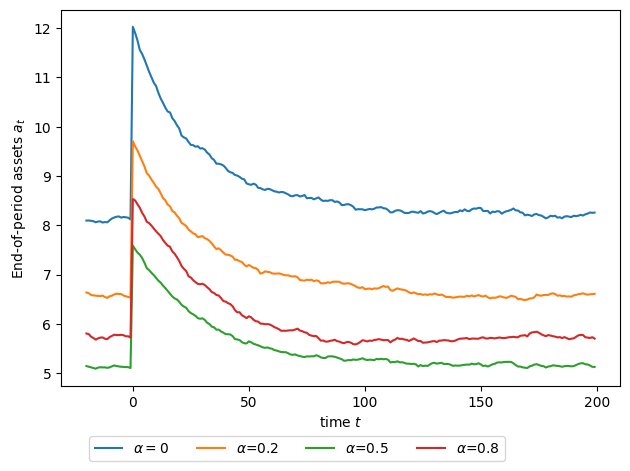

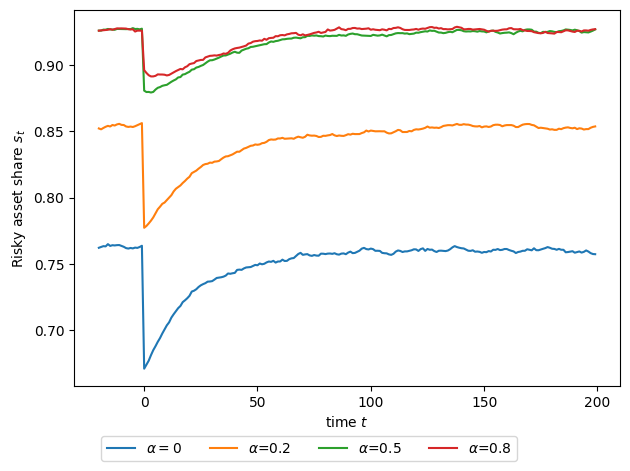

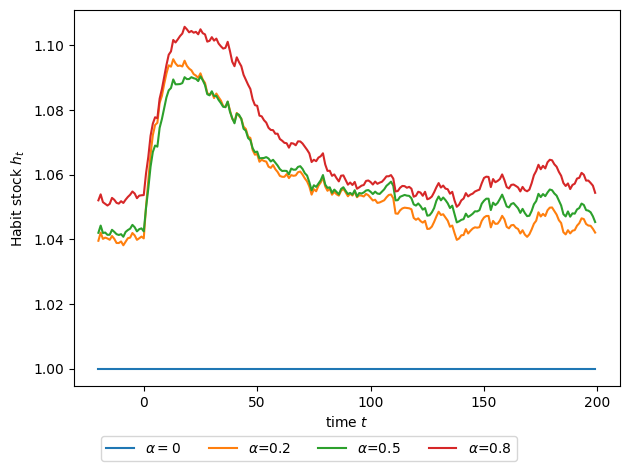

In [13]:
# Plot the results of the positive wealth shock experiment
draw_four_plots(CASH_pos_wealth, T_burn, type_labels)

In [14]:
# Run an experiment in which the habit stock is shocked downward by 50%
t0 = time()
CASH_neg_habit = run_experiment_on_types(my_agents, "HNrm", 0.5, T_burn)
t1 = time()
print("The negative habit shock experiment took " + mystr(t1 - t0) + " seconds.")

The negative habit shock experiment took 46.473 seconds.


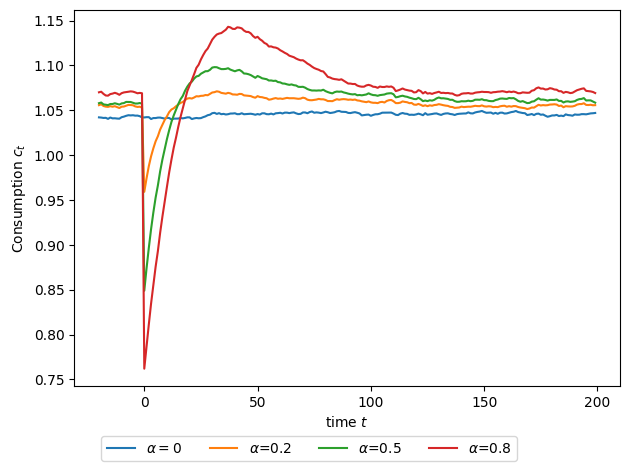

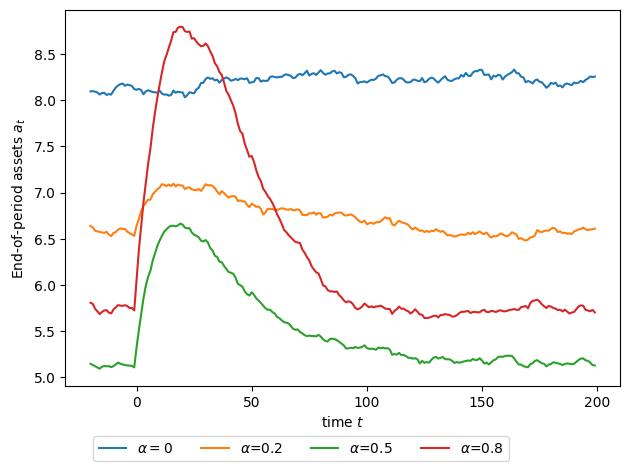

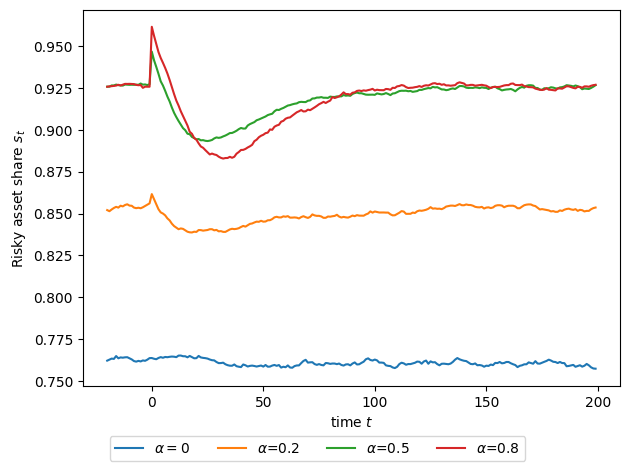

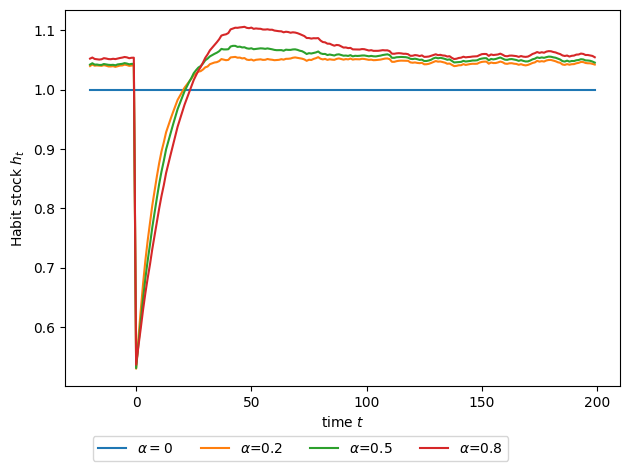

In [15]:
# Plot the results of the negative habit shock experiment
draw_four_plots(CASH_neg_habit, T_burn, type_labels)

In [16]:
# Run an experiment in which the habit stock is shocked upward by 50%
t0 = time()
CASH_pos_habit = run_experiment_on_types(my_agents, "HNrm", 1.5, T_burn)
t1 = time()
print("The positive habit shock experiment took " + mystr(t1 - t0) + " seconds.")

The positive habit shock experiment took 46.884 seconds.


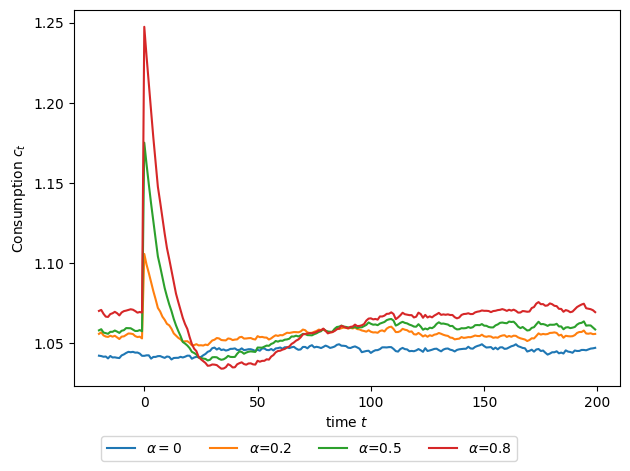

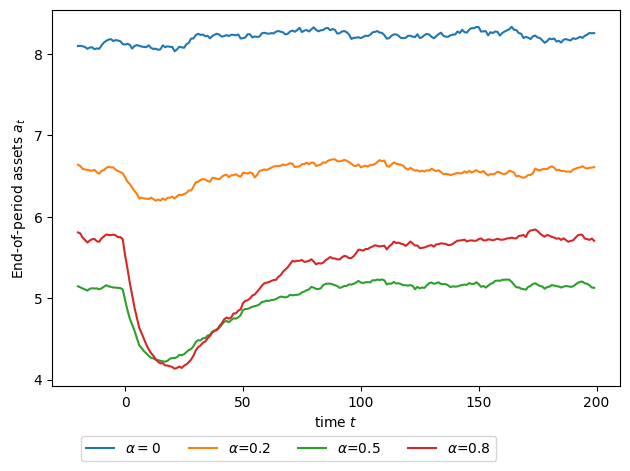

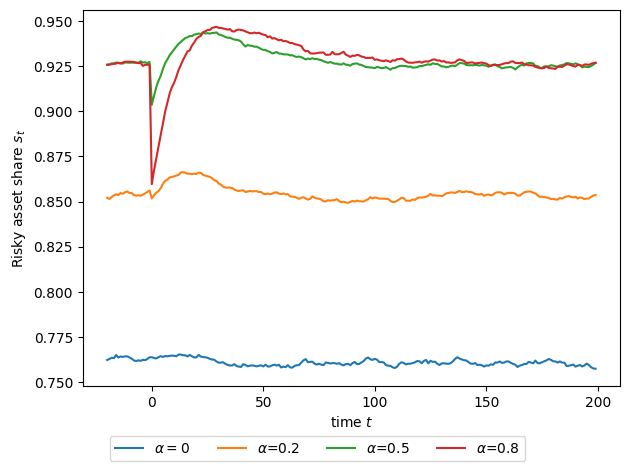

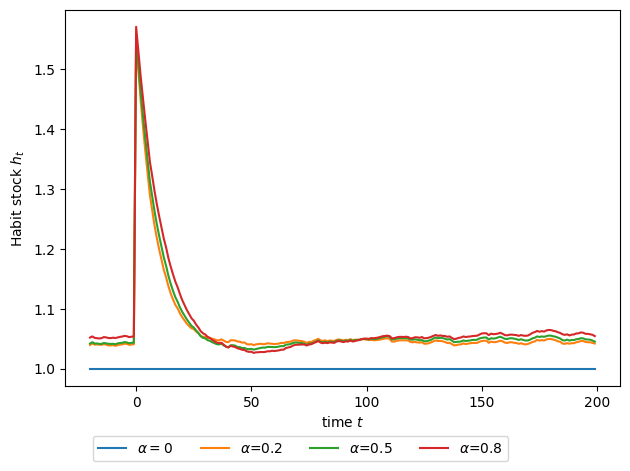

In [17]:
# Plot the results of the positive habit shock experiment
draw_four_plots(CASH_pos_habit, T_burn, type_labels)